# Concept 55 – Planning Systems in LangGraph
## ReAct · Plan-and-Execute · Task Decomposition · Dynamic Planning · Goal-oriented · Hierarchical

---

## Why planning makes systems truly agentic

A basic LLM answers one question and stops.
An **agentic system** decides *what to do*, *in what order*, and *when it is done* — that is planning.

Without planning, an AI system is a fancy autocomplete.
With planning, it becomes an autonomous agent that can tackle multi-step, open-ended problems.

---

## The six planning patterns — and the problem each one solves

| Pattern | The problem it solves | When to use it |
|---|---|---|
| **ReAct** | Agent needs to interleave reasoning and acting | Open-ended tasks where the next step depends on what you just learned |
| **Plan-and-Execute** | Acting without a plan wastes steps | Tasks with a knowable structure upfront |
| **Task Decomposition** | Complex tasks are too big to solve directly | Large goals that must be broken into manageable pieces |
| **Dynamic Planning** | Rigid plans break on unexpected results | Real-world tasks where failures and surprises are common |
| **Goal-oriented** | Agent loses track of what 'done' looks like | Tasks with explicit success criteria that must be checked |
| **Hierarchical** | All complexity at one level is unmanageable | Large systems that need orchestrators and specialists |

---

## Consistent scenario throughout this notebook

Every planning pattern is demonstrated with the **same domain**:  
planning an AI skills development journey for a student.

This makes the patterns easy to compare — you can see how each one approaches the same underlying problem differently.

```
Tools available to the agent:
  search_resources(topic)           → find learning materials
  check_prerequisites(skill)        → what must be learned first
  estimate_time(task)               → how long a task takes
  assess_difficulty(topic, level)   → is this appropriate for the learner
  save_progress(milestone, status)  → record what is done
  get_progress()                    → read current progress
  create_schedule(tasks, hours)     → build a weekly schedule
```

## Step 1 – Install, Setup, and Define Tools

In [1]:
%pip install -q langchain-anthropic langgraph pydantic


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain.tools import tool

load_dotenv(override=True)

# ── Base LLM ───────────────────────────────────────────────────────────────────
# Used in every planning pattern throughout this notebook.
# temperature=0 keeps reasoning steps deterministic and reproducible.
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0)

# ── Mock knowledge base ────────────────────────────────────────────────────────
# Pre-loaded data that the tools will query.
# In production these would be real database or API calls.

RESOURCES = {
    "python":          ["Python Basics (20h)", "Python for AI (15h)"],
    "langchain":       ["LangChain Fundamentals (12h)", "LangChain Advanced (18h)"],
    "langgraph":       ["LangGraph Core (15h)", "LangGraph Patterns (20h)"],
    "machine learning":["ML Foundations (40h)", "Practical ML (30h)"],
    "mcp":             ["MCP Basics (10h)", "Building MCP Servers (15h)"],
    "a2a":             ["A2A Protocol (10h)", "Multi-Agent A2A (20h)"],
    "ai agents":       ["Agent Design (25h)", "Multi-Agent Systems (30h)"],
}

PREREQUISITES = {
    "langchain":        ["python"],
    "langgraph":        ["python", "langchain"],
    "ai agents":        ["langgraph"],
    "mcp":              ["python"],
    "a2a":              ["mcp", "ai agents"],
    "machine learning": ["python"],
    "python":           [],
}

DIFFICULTY = {
    "python":           {"beginner": "easy",   "intermediate": "easy",   "advanced": "easy"},
    "langchain":        {"beginner": "hard",   "intermediate": "medium", "advanced": "easy"},
    "langgraph":        {"beginner": "hard",   "intermediate": "medium", "advanced": "easy"},
    "machine learning": {"beginner": "hard",   "intermediate": "medium", "advanced": "medium"},
    "ai agents":        {"beginner": "hard",   "intermediate": "hard",   "advanced": "medium"},
    "mcp":              {"beginner": "medium", "intermediate": "easy",   "advanced": "easy"},
    "a2a":              {"beginner": "hard",   "intermediate": "medium", "advanced": "easy"},
}

TIME_ESTIMATES = {
    "read documentation": 3,
    "complete tutorial":  8,
    "build project":      16,
    "review concepts":    2,
    "practice exercises": 5,
    "default":            6,
}

# In-memory store for save_progress / get_progress tools
progress_store: dict = {}


# ── Tool definitions ───────────────────────────────────────────────────────────
# All tools are deterministic mock functions so examples run without external APIs.

@tool
def search_resources(topic: str) -> str:
    """Search for learning resources on a given topic."""
    key = topic.lower().strip()
    matches = {
        k: v for k, v in RESOURCES.items()
        if key in k or k in " ".join(v).lower()
    }
    if not matches:
        return f"No resources found for '{topic}'. Try: {list(RESOURCES.keys())}"
    lines = [f"  [{k}]: {', '.join(v)}" for k, v in matches.items()]
    return f"Resources for '{topic}':\n" + "\n".join(lines)

@tool
def check_prerequisites(skill: str) -> str:
    """Check which skills must be learned before starting this skill."""
    key = skill.lower().strip()
    prereqs = PREREQUISITES.get(key, None)
    if prereqs is None:
        return f"No prerequisite data for '{skill}'."
    if not prereqs:
        return f"'{skill}' has no prerequisites — safe to start immediately."
    return f"Prerequisites for '{skill}': {prereqs}. Learn these first."

@tool
def estimate_time(task: str) -> str:
    """Estimate how many hours a learning task will take."""
    key = task.lower().strip()
    for phrase, hours in TIME_ESTIMATES.items():
        if phrase in key:
            return f"Estimated time for '{task}': {hours} hours."
    # Heuristic: count resources if a topic is given
    for topic, resources in RESOURCES.items():
        if topic in key:
            total = sum(int(r.split('(')[1].replace('h)', '')) for r in resources)
            return f"Estimated time to complete all '{topic}' resources: {total} hours."
    return f"Estimated time for '{task}': {TIME_ESTIMATES['default']} hours (default estimate)."

@tool
def assess_difficulty(topic: str, experience_level: str) -> str:
    """Assess how difficult a topic is for someone at a given experience level (beginner/intermediate/advanced)."""
    key = topic.lower().strip()
    level = experience_level.lower().strip()
    topic_data = DIFFICULTY.get(key)
    if not topic_data:
        return f"No difficulty data for '{topic}'."
    difficulty = topic_data.get(level, "unknown")
    return f"Difficulty of '{topic}' for a {level}: {difficulty}."

@tool
def save_progress(milestone: str, status: str) -> str:
    """Save progress on a learning milestone. status should be: planned / in-progress / completed."""
    progress_store[milestone] = status
    return f"Progress saved: '{milestone}' → {status}"

@tool
def get_progress() -> str:
    """Retrieve all saved learning milestones and their status."""
    if not progress_store:
        return "No progress recorded yet."
    lines = [f"  {m}: {s}" for m, s in progress_store.items()]
    return "Current progress:\n" + "\n".join(lines)

@tool
def create_schedule(tasks: str, hours_per_week: int) -> str:
    """Create a weekly learning schedule. tasks is a comma-separated list of task names."""
    task_list = [t.strip() for t in tasks.split(",") if t.strip()]
    schedule = []
    week = 1
    weekly_hours = 0
    for task in task_list:
        hours = TIME_ESTIMATES.get(task.lower(), TIME_ESTIMATES["default"])
        weeks_needed = -(-hours // hours_per_week)  # ceiling division
        schedule.append(f"  Week {week}–{week + weeks_needed - 1}: {task} ({hours}h)")
        week += weeks_needed
    return f"Schedule ({hours_per_week}h/week):\n" + "\n".join(schedule) + f"\n  Total: {week - 1} weeks"


ALL_TOOLS = [search_resources, check_prerequisites, estimate_time,
             assess_difficulty, save_progress, get_progress, create_schedule]

print("Setup complete.")
print(f"LLM     : {llm.model}")
print(f"Tools   : {[t.name for t in ALL_TOOLS]}")

/Users/utsabchakraborty/Documents/Edureka_May2026/LangGraph/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.
LLM     : claude-haiku-4-5-20251001
Tools   : ['search_resources', 'check_prerequisites', 'estimate_time', 'assess_difficulty', 'save_progress', 'get_progress', 'create_schedule']


---
## Step 2 – ReAct: Reason → Act → Observe → Repeat

**ReAct** (Reasoning + Acting) is the foundational planning pattern.
The agent alternates between two steps:

1. **Reason** — think about the current situation and what to do next (the LLM's internal monologue)
2. **Act** — call a tool to gather information or make something happen
3. **Observe** — receive the tool result and fold it into the next reasoning step
4. **Repeat** — keep going until the goal is reached

```
START
  │
  ▼
[Reason] → decide which tool to call
  │
  ▼
[Act]    → call the tool
  │
  ▼
[Observe] → read the tool result
  │
  ├── need more info? → back to [Reason]
  └── goal achieved?  → END
```

**When to use ReAct:**  
The next step cannot be determined upfront — it depends on what previous steps returned.  
Example: "Research what I need to learn" — you don't know what to search until you see prerequisites.

**Limitation of ReAct:**  
It is reactive — it discovers the path step by step. For well-structured problems this is inefficient;  
Plan-and-Execute (Step 3) is better when the full plan is knowable upfront.

In [3]:
from langgraph.prebuilt import create_react_agent

# create_react_agent builds the Reason-Act-Observe loop automatically.
# Internally it is: START → agent_node ⇄ tools_node → END
# The agent_node runs the LLM; tools_node executes any tool_calls.
react_agent = create_react_agent(llm, tools=ALL_TOOLS)

task = (
    "I am a complete beginner. I want to learn how to build AI agents with LangGraph. "
    "Figure out what I need to learn, check prerequisites, assess difficulty for a beginner, "
    "and save a learning plan as milestones."
)

print("TASK:", task)
print("\n" + "=" * 65)
print("ReAct AGENT TRACE — Reason → Act → Observe loop")
print("=" * 65)

result = react_agent.invoke({"messages": [("user", task)]})

# Show every message — this reveals the full ReAct reasoning trace
for msg in result["messages"]:
    msg.pretty_print()

print("\n" + "=" * 65)
print("PROGRESS SAVED BY THE REACT AGENT:")
print(get_progress.invoke({}))

/var/folders/1h/8kw0jbt134d6sgxbnf23qrhr0000gn/T/ipykernel_55245/82813893.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_agent = create_react_agent(llm, tools=ALL_TOOLS)


TASK: I am a complete beginner. I want to learn how to build AI agents with LangGraph. Figure out what I need to learn, check prerequisites, assess difficulty for a beginner, and save a learning plan as milestones.

ReAct AGENT TRACE — Reason → Act → Observe loop
================================ Human Message =================================

I am a complete beginner. I want to learn how to build AI agents with LangGraph. Figure out what I need to learn, check prerequisites, assess difficulty for a beginner, and save a learning plan as milestones.
================================== Ai Message ==================================

[{'text': "I'll help you create a comprehensive learning plan for building AI agents with LangGraph. Let me start by gathering information about what you need to learn, checking prerequisites, and assessing the difficulty.", 'type': 'text'}, {'id': 'toolu_01PkMSQqQZM7xNAqMzyt9vU4', 'caller': {'type': 'direct'}, 'input': {'topic': 'LangGraph AI agents'}, 'name':

---
## Step 3 – Plan-and-Execute: Think First, Then Act

**Plan-and-Execute** separates planning from execution into two distinct phases:

- **Phase 1 — Planner**: The LLM produces a complete, structured plan **before** taking any action.
- **Phase 2 — Executor**: A separate agent (or the same agent) executes each step of the plan in order.

```
START
  │
  ▼
[Planner]  ← LLM creates a full plan (list of steps) using structured output
  │
  ▼
[Executor] ← executes step 1
  │
  ▼
[Executor] ← executes step 2
  │
 ...
  ▼
[Executor] ← executes step N
  │
  ▼
 END
```

**Why it beats ReAct for structured tasks:**  
The plan is visible, auditable, and can be reviewed or modified before execution starts.
Execution is also more efficient because the LLM is not re-reasoning from scratch at every step.

**Key insight — structured output for plans:**  
We use a Pydantic model for the plan (from Concept 54) so the planner's output is always a typed object,  
not free-form text. The executor can iterate over `plan.steps` reliably.

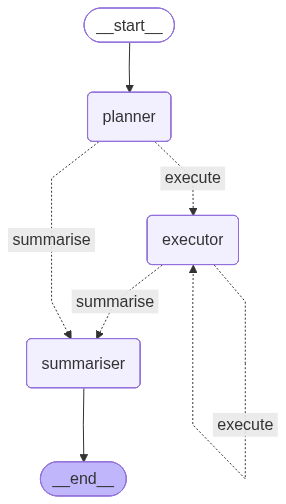

In [4]:
from pydantic import BaseModel, Field
from typing import List, Optional, Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# ── Plan schema ────────────────────────────────────────────────────────────────
class PlanStep(BaseModel):
    """A single step in the learning plan."""
    step_id:     int = Field(description="Sequential step number starting from 1")
    description: str = Field(description="What to do in this step — be specific and actionable")
    tool:        str = Field(description="The tool name to call for this step")
    tool_input:  str = Field(description="The exact input string to pass to the tool")
    rationale:   str = Field(description="Why this step is needed in the plan")

class LearningPlan(BaseModel):
    """A structured plan for achieving a learning goal."""
    goal:             str            = Field(description="The high-level learning goal")
    steps:            List[PlanStep] = Field(description="Ordered list of steps to achieve the goal")
    expected_outcome: str            = Field(description="What will have been accomplished when all steps complete")

# ── Graph state ────────────────────────────────────────────────────────────────
class PlanExecuteState(TypedDict):
    task:          str
    plan:          Optional[LearningPlan]
    current_step:  int
    results:       List[str]
    final_summary: Optional[str]

# ── Phase 1: Planner node ─────────────────────────────────────────────────────
planner_llm = llm.with_structured_output(LearningPlan)

def planner_node(state: PlanExecuteState) -> dict:
    """
    Creates the full plan BEFORE any execution begins.
    Uses structured output so the plan is always a typed LearningPlan object.
    """
    plan = planner_llm.invoke(
        f"Create a detailed step-by-step plan to accomplish this learning goal:\n"
        f"Goal: {state['task']}\n"
        f"Available tools: search_resources, check_prerequisites, estimate_time, "
        f"assess_difficulty, save_progress, create_schedule\n"
        f"IMPORTANT for multi-arg tools: separate arguments with a pipe character |:\n"
        f"  assess_difficulty  → tool_input: 'LangGraph|intermediate'\n"
        f"  save_progress      → tool_input: 'Week1 milestone|completed'\n"
        f"  create_schedule    → tool_input: 'read docs,build project|8'\n"
        f"Single-arg tools (search_resources, check_prerequisites, estimate_time) "
        f"just take a plain string with no pipe.\n"
        f"Each step must specify exactly one tool and the correct input format."
    )
    print(f"  [Planner] Created plan with {len(plan.steps)} steps")
    for s in plan.steps:
        print(f"    Step {s.step_id}: {s.tool}('{s.tool_input}')")
    return {"plan": plan, "current_step": 0, "results": []}

# ── Helper: safe two-arg split ────────────────────────────────────────────────
def _safe_split(tool_input: str, default_second: str):
    """Split on | for two-arg tools. Use default_second if | is missing."""
    parts = tool_input.split("|", 1)
    return parts[0].strip(), (parts[1].strip() if len(parts) > 1 else default_second)

# ── Phase 2: Executor node ────────────────────────────────────────────────────
TOOL_MAP = {t.name: t for t in ALL_TOOLS}

def executor_node(state: PlanExecuteState) -> dict:
    """
    Executes one step at a time. Wrapped in try-except so a bad step
    never crashes the entire graph — it records an error and moves on.
    """
    # Coerce dict → LearningPlan in case LangGraph deserialized the Pydantic object
    plan = state["plan"]
    if isinstance(plan, dict):
        plan = LearningPlan(**plan)

    step = plan.steps[state["current_step"]]
    if isinstance(step, dict):
        step = PlanStep(**step)

    print(f"  [Executor] Step {step.step_id}: {step.description}")
    tool_fn = TOOL_MAP.get(step.tool)
    result  = f"[Tool '{step.tool}' not found in registry]"

    if tool_fn:
        try:
            if step.tool == "create_schedule":
                tasks, hrs = _safe_split(step.tool_input, "5")
                result = tool_fn.invoke({"tasks": tasks, "hours_per_week": int(hrs) if hrs.isdigit() else 5})
            elif step.tool == "assess_difficulty":
                topic, level = _safe_split(step.tool_input, "intermediate")
                result = tool_fn.invoke({"topic": topic, "experience_level": level})
            elif step.tool == "save_progress":
                milestone, status = _safe_split(step.tool_input, "completed")
                result = tool_fn.invoke({"milestone": milestone, "status": status})
            else:
                result = tool_fn.invoke(step.tool_input)
        except Exception as e:
            result = f"[Step error: {str(e)[:100]}]"

    result_str = str(result)
    print(f"    → {result_str[:120]}")
    return {
        "current_step": state["current_step"] + 1,
        "results": state["results"] + [f"Step {step.step_id} ({step.tool}): {result_str[:150]}"],
    }

# ── Summariser node ───────────────────────────────────────────────────────────
def summariser_node(state: PlanExecuteState) -> dict:
    """Synthesises all step results into a final human-readable summary."""
    plan = state["plan"]
    if isinstance(plan, dict):
        plan = LearningPlan(**plan)
    goal         = plan.goal if plan else state["task"]
    results_text = "\n".join(state["results"]) if state["results"] else "No steps executed."
    summary = llm.invoke(
        f"Goal: {goal}\n"
        f"Execution results:\n{results_text}\n"
        f"Write a concise summary of what was accomplished and what the learner should do next."
    ).content
    return {"final_summary": summary}

# ── Routing ───────────────────────────────────────────────────────────────────
def should_continue_executing(state: PlanExecuteState) -> str:
    """Route back to executor until all plan steps are done."""
    plan = state.get("plan")
    if plan is None:
        return "summarise"
    # Handle both Pydantic model and dict (LangGraph may deserialize to dict)
    steps = plan.steps if hasattr(plan, "steps") else plan.get("steps", [])
    if state["current_step"] < len(steps):
        return "execute"
    return "summarise"

# ── Build the graph ────────────────────────────────────────────────────────────
progress_store.clear()

builder = StateGraph(PlanExecuteState)
builder.add_node("planner",    planner_node)
builder.add_node("executor",   executor_node)
builder.add_node("summariser", summariser_node)

builder.add_edge(START, "planner")
builder.add_conditional_edges("planner",  should_continue_executing,
                               {"execute": "executor", "summarise": "summariser"})
builder.add_conditional_edges("executor", should_continue_executing,
                               {"execute": "executor", "summarise": "summariser"})
builder.add_edge("summariser", END)

plan_execute_graph = builder.compile()
display(Image(plan_execute_graph.get_graph().draw_mermaid_png()))


In [5]:
print("=" * 65)
print("PLAN-AND-EXECUTE RUN")
print("=" * 65)

task = "Build a 3-month learning path for an intermediate Python developer who wants to master AI agent development with LangGraph, MCP, and A2A."
print(f"TASK: {task}\n")

result = plan_execute_graph.invoke({
    "task":          task,
    "plan":          None,
    "current_step":  0,
    "results":       [],
    "final_summary": None,
})

print("\n=== FINAL SUMMARY ===")
print(result["final_summary"])

PLAN-AND-EXECUTE RUN
TASK: Build a 3-month learning path for an intermediate Python developer who wants to master AI agent development with LangGraph, MCP, and A2A.

  [Planner] Created plan with 14 steps
    Step 1: search_resources('LangGraph fundamentals tutorials documentation')
    Step 2: check_prerequisites('LangGraph prerequisites async Python LLM APIs')
    Step 3: assess_difficulty('LangGraph|intermediate')
    Step 4: search_resources('Model Context Protocol MCP implementation integration LangGraph')
    Step 5: check_prerequisites('MCP prerequisites protocol design tool integration')
    Step 6: assess_difficulty('MCP implementation|intermediate')
    Step 7: search_resources('Agent-to-Agent A2A communication multi-agent systems coordination')
    Step 8: check_prerequisites('A2A prerequisites distributed systems message passing agent coordination')
    Step 9: assess_difficulty('A2A implementation|intermediate')
    Step 10: estimate_time('LangGraph mastery intermediate de

---
## Step 4 – Task Decomposition: Break It Down

**Task Decomposition** is the strategy of taking a complex, high-level task and recursively breaking it into simpler pieces until each piece is small enough to execute directly.

- **Composite task**: too complex to execute — must be broken into subtasks
- **Atomic task**: simple enough to execute with a single tool call

```
"Master AI Agents"
    ├── "Learn Python"            ← atomic (directly executable)
    ├── "Learn LangGraph"
    │     ├── "Read LangGraph docs"  ← atomic
    │     └── "Build a graph project" ← atomic
    └── "Learn Multi-Agent Patterns"
          ├── "Study MCP protocol"   ← atomic
          └── "Study A2A protocol"   ← atomic
```

**Why decomposition matters:**  
Large goals are impossible to execute directly. Decomposition creates a work-breakdown structure (WBS) — the same technique used in project management — so an agent can make steady, measurable progress.

**Connection to Plan-and-Execute:**  
Task decomposition often feeds INTO Plan-and-Execute: first decompose the goal into atomic tasks,  
then execute each atomic task with the executor.

In [8]:
from pydantic import BaseModel, Field
from typing import List, Optional


# ── Recursive task schema ──────────────────────────────────────────────────────
class Task(BaseModel):
    """
    A task that is either atomic (directly executable) or composite (must be broken down).
    Pydantic supports recursive models — a Task can contain a list of Tasks.
    """
    name:        str  = Field(description="Short name for this task")
    description: str  = Field(description="What this task accomplishes")
    is_atomic:   bool = Field(description="True if this task can be executed directly with one tool call; False if it needs further decomposition")
    tool:        Optional[str]  = Field(default=None, description="Tool to use if is_atomic=True")
    tool_input:  Optional[str]  = Field(default=None, description="Input for the tool if is_atomic=True")
    subtasks:    Optional[List["Task"]] = Field(default=None, description="Subtasks if is_atomic=False")
    estimated_hours: float = Field(description="Estimated hours to complete this task")

# Required for recursive Pydantic models
Task.model_rebuild()


# ── Decomposer LLM ─────────────────────────────────────────────────────────────
decomposer_llm = llm.with_structured_output(Task)

def decompose(goal: str, max_depth: int = 2, current_depth: int = 0) -> Task:
    """
    Recursively decomposes a goal into atomic tasks.
    The LLM decides whether each task is atomic or needs further decomposition.
    max_depth guards against infinite recursion.
    """
    at_max = current_depth >= max_depth
    depth_instruction = (
        "You are at maximum depth. Mark ALL tasks as is_atomic=True — no more subtasks."
    ) if at_max else (
        "Mark is_atomic=True for tasks executable with ONE tool call. "
        "Mark is_atomic=False for tasks that need up to 3 subtasks. "
        "Keep subtask lists SHORT (max 3 items)."
    )
    print(f"  [Decompose] depth={current_depth}  goal='{goal[:60]}'")

    task = decomposer_llm.invoke(
        f"Decompose this goal into a task tree:\n"
        f"Goal: {goal}\n"
        f"Available tools: search_resources, check_prerequisites, estimate_time, assess_difficulty, save_progress\n"
        f"{depth_instruction}\n"
        f"Each atomic task MUST specify which tool to call and its input."
    )

    # Recursively decompose non-atomic subtasks
    if not task.is_atomic and task.subtasks and current_depth < max_depth:
        refined_subtasks = []
        for subtask in task.subtasks:
            if not subtask.is_atomic:
                refined_subtasks.append(decompose(subtask.description, max_depth, current_depth + 1))
            else:
                refined_subtasks.append(subtask)
        task.subtasks = refined_subtasks

    return task


def print_task_tree(task: Task, indent: int = 0) -> list:
    """Pretty-print the task tree and collect atomic tasks."""
    prefix = "  " * indent
    icon = "🔧" if task.is_atomic else "📋"
    print(f"{prefix}{icon} {task.name} ({task.estimated_hours}h)")
    print(f"{prefix}   {task.description}")
    if task.is_atomic and task.tool:
        print(f"{prefix}   → {task.tool}('{task.tool_input}')")

    atomic_tasks = []
    if task.is_atomic:
        atomic_tasks.append(task)
    elif task.subtasks:
        for sub in task.subtasks:
            atomic_tasks.extend(print_task_tree(sub, indent + 1))
    return atomic_tasks


# ── Run the decomposer ─────────────────────────────────────────────────────────
print("=" * 65)
print("TASK DECOMPOSITION")
print("=" * 65)

goal = "Master LangGraph for building production AI agents as a beginner Python developer"
print(f"Goal: {goal}\n")

task_tree = decompose(goal, max_depth=2)

print("\n── Task Tree ──")
atomic_tasks = print_task_tree(task_tree)

total_hours = sum(t.estimated_hours for t in atomic_tasks)
print(f"\n── Summary ──")
print(f"Total atomic tasks : {len(atomic_tasks)}")
print(f"Total estimated time: {total_hours:.0f} hours")
print(f"Atomic tasks ready to execute:")
for i, t in enumerate(atomic_tasks, 1):
    print(f"  {i}. {t.name} → {t.tool}('{t.tool_input}')")

TASK DECOMPOSITION
Goal: Master LangGraph for building production AI agents as a beginner Python developer

  [Decompose] depth=0  goal='Master LangGraph for building production AI agents as a begi'
  [Decompose] depth=1  goal='Evaluate current Python skills and identify prerequisite kno'
  [Decompose] depth=2  goal='Compile assessment results and save progress for future refe'
  [Decompose] depth=1  goal='Build foundational knowledge of LangGraph architecture, core'
  [Decompose] depth=2  goal='Understand the core architectural components and design patt'
  [Decompose] depth=2  goal='Deep dive into key LangGraph concepts and common usage patte'
  [Decompose] depth=2  goal='Develop hands-on experience by working through basic LangGra'
  [Decompose] depth=2  goal='Evaluate understanding and document key learnings from the f'
  [Decompose] depth=1  goal='Develop proficiency with advanced features, tool integration'
  [Decompose] depth=2  goal='Learn and practice advanced features and tec

KeyboardInterrupt: 

---
## Step 5 – Dynamic Planning: Adapt When Things Change

**Dynamic Planning** is Plan-and-Execute with one crucial addition: **the plan can change during execution**.

Static plans fail in the real world because:
- A tool returns an unexpected result that makes the next step irrelevant
- A step fails and an alternative approach is needed
- New information discovered mid-execution changes the strategy

```
START → [Planner] → [Executor] → ✅ success → next step
                               → ❌ failure → [Replanner] → revised plan → [Executor]
```

**Key components:**
- **Replanner node**: receives the failed step + completed results + original goal → produces a revised plan
- **Failure detection**: the executor categorises results as success or failure
- **Replan limit**: prevents infinite replanning loops (max 3 replans)

**When to use dynamic planning:**  
Any time the environment is uncertain or steps can fail — external APIs, user input, web searches.

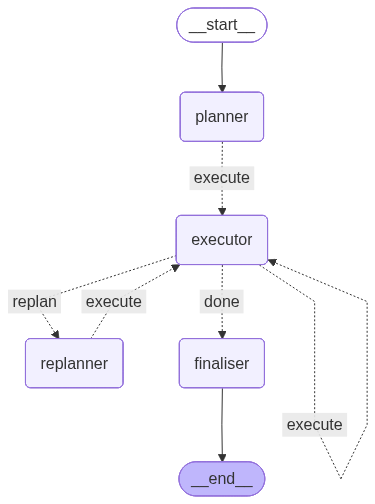

In [9]:
from typing import TypedDict, List, Optional
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END


# ── Plan and state schemas ─────────────────────────────────────────────────────
class DynamicPlanStep(BaseModel):
    step_id:    int
    action:     str = Field(description="What to do")
    tool:       str = Field(description="Tool to use")
    tool_input: str = Field(description="Input for the tool")

class DynamicPlan(BaseModel):
    goal:   str
    steps:  List[DynamicPlanStep]
    reason: str = Field(description="Why this plan will achieve the goal")

class DynamicState(TypedDict):
    goal:          str
    plan:          Optional[DynamicPlan]
    current_step:  int
    completed:     List[str]
    failed_steps:  List[str]
    replan_count:  int
    final_answer:  Optional[str]


# ── Simulated failure: make one tool return a 'failure' to trigger replanning ──
SIMULATED_FAILURES = {"machine learning"}  # pretend this resource is unavailable

@tool
def search_resources_flaky(topic: str) -> str:
    """Search for learning resources — may return unavailable for some topics."""
    if topic.lower().strip() in SIMULATED_FAILURES:
        return f"ERROR: Resources for '{topic}' are currently unavailable. Try a different topic."
    return search_resources.invoke(topic)


# ── Nodes ──────────────────────────────────────────────────────────────────────
dynamic_planner_llm   = llm.with_structured_output(DynamicPlan)
dynamic_replanner_llm = llm.with_structured_output(DynamicPlan)

def initial_planner(state: DynamicState) -> dict:
    """Creates the first plan for the goal."""
    plan = dynamic_planner_llm.invoke(
        f"Create a step-by-step plan for: {state['goal']}\n"
        f"Tools: search_resources_flaky, check_prerequisites, estimate_time, save_progress"
    )
    print(f"  [Initial Planner] Plan: {[s.action for s in plan.steps]}")
    return {"plan": plan, "current_step": 0}

def dynamic_executor(state: DynamicState) -> dict:
    """Executes one step. Marks it as completed or failed."""
    step = state["plan"].steps[state["current_step"]]
    print(f"  [Executor] Step {step.step_id}: {step.action}")

    tool_fn = {"search_resources_flaky": search_resources_flaky,
               "check_prerequisites":    check_prerequisites,
               "estimate_time":          estimate_time,
               "save_progress":          save_progress}.get(step.tool)

    if tool_fn:
        if step.tool == "save_progress":
            parts = step.tool_input.split("|")
            result = tool_fn.invoke({"milestone": parts[0].strip(), "status": parts[1].strip() if len(parts) > 1 else "planned"})
        else:
            result = tool_fn.invoke(step.tool_input)
    else:
        result = f"Tool '{step.tool}' not found."

    print(f"    → {result[:120]}")

    # Treat ERROR responses as failures that trigger replanning
    if result.startswith("ERROR"):
        print(f"    ⚠️  FAILURE DETECTED — will trigger replanning")
        return {
            "current_step":  state["current_step"] + 1,
            "failed_steps":  state["failed_steps"] + [f"Step {step.step_id}: {step.action} → {result}"],
        }
    return {
        "current_step": state["current_step"] + 1,
        "completed":    state["completed"] + [f"Step {step.step_id}: {result[:80]}"],
    }

def replanner_node(state: DynamicState) -> dict:
    """
    Called when a step fails. Produces a NEW plan that:
    - acknowledges the failure
    - uses what was already completed
    - avoids the failed approach
    """
    print(f"  [Replanner] Replanning (attempt {state['replan_count'] + 1})...")
    revised_plan = dynamic_replanner_llm.invoke(
        f"Original goal: {state['goal']}\n"
        f"Already completed:\n" + "\n".join(state["completed"]) + "\n"
        f"Failed steps (do NOT repeat these approaches):\n" + "\n".join(state["failed_steps"]) + "\n"
        f"Create a REVISED plan that avoids the failed steps and achieves the goal with what remains.\n"
        f"Tools: search_resources_flaky, check_prerequisites, estimate_time, save_progress"
    )
    print(f"    Revised plan: {[s.action for s in revised_plan.steps]}")
    return {"plan": revised_plan, "current_step": 0, "replan_count": state["replan_count"] + 1}

def finaliser(state: DynamicState) -> dict:
    summary = llm.invoke(
        f"Goal: {state['goal']}\nCompleted: {state['completed']}\nFailed: {state['failed_steps']}\n"
        f"Replanning occurred {state['replan_count']} time(s).\nSummarise what was accomplished."
    ).content
    return {"final_answer": summary}

# ── Routing ────────────────────────────────────────────────────────────────────
def route_after_execution(state: DynamicState) -> str:
    """Three possible routes after each execution step."""
    if state["failed_steps"] and state["replan_count"] < 3:
        return "replan"     # there was a failure → go to replanner
    if state["current_step"] < len(state["plan"].steps):
        return "execute"    # more steps remain → keep executing
    return "done"           # all steps done → finalise

# ── Build graph ────────────────────────────────────────────────────────────────
progress_store.clear()

builder = StateGraph(DynamicState)
builder.add_node("planner",  initial_planner)
builder.add_node("executor", dynamic_executor)
builder.add_node("replanner",replanner_node)
builder.add_node("finaliser",finaliser)

builder.add_edge(START, "planner")
builder.add_conditional_edges("planner",   lambda s: "execute", {"execute": "executor"})
builder.add_conditional_edges("executor",  route_after_execution,
                               {"replan": "replanner", "execute": "executor", "done": "finaliser"})
builder.add_conditional_edges("replanner", lambda s: "execute", {"execute": "executor"})
builder.add_edge("finaliser", END)

dynamic_graph = builder.compile()
display(Image(dynamic_graph.get_graph().draw_mermaid_png()))

In [10]:
print("=" * 65)
print("DYNAMIC PLANNING RUN — with simulated failure on 'machine learning'")
print("=" * 65)

result = dynamic_graph.invoke({
    "goal":         "Find resources and prerequisites for learning machine learning and LangGraph",
    "plan":         None,
    "current_step": 0,
    "completed":    [],
    "failed_steps": [],
    "replan_count": 0,
    "final_answer": None,
})

print(f"\nReplanning occurred: {result['replan_count']} time(s)")
print("\n=== FINAL ANSWER ===")
print(result["final_answer"])

DYNAMIC PLANNING RUN — with simulated failure on 'machine learning'
  [Initial Planner] Plan: ['Check the prerequisites needed for learning machine learning and LangGraph', 'Search for quality resources on machine learning fundamentals', 'Search for LangGraph-specific learning resources and documentation', 'Estimate the time required to learn machine learning and LangGraph', 'Save your learning plan and progress tracking setup']
  [Executor] Step 1: Check the prerequisites needed for learning machine learning and LangGraph
    → No prerequisite data for 'machine learning and LangGraph'.
  [Executor] Step 2: Search for quality resources on machine learning fundamentals
    → Resources for 'machine learning fundamentals tutorials courses':
  [python]: Python Basics (20h), Python for AI (15h)
  
  [Executor] Step 3: Search for LangGraph-specific learning resources and documentation
    → Resources for 'LangGraph tutorials documentation guides':
  [python]: Python Basics (20h), Python for 

---
## Step 6 – Goal-oriented Execution: Keep Going Until Done

**Goal-oriented execution** starts from the end, not the beginning:
1. Define the **goal** clearly
2. Define **success criteria** — measurable conditions that, when all met, mean the goal is achieved
3. Execute actions, then **check progress** against criteria after each iteration
4. Keep iterating until all criteria are met — or a timeout stops the loop

```
START
  │
  ▼
[Define goal + criteria]
  │
  ▼
[Execute next action]   ←──────────────┐
  │                                    │
  ▼                                    │
[Check: all criteria met?]             │
  │                                    │
  ├── No, criteria unmet → [Decide next action] ──┘
  ├── Yes, all met → END (success)
  └── Timeout (max iterations) → END (partial)
```

**Key difference from Plan-and-Execute:**  
In Plan-and-Execute, the agent runs a fixed list of steps then stops.  
In Goal-oriented execution, the agent keeps going **until the goal is actually satisfied** — it does not matter how many steps that takes.

**Use case:**  
Research tasks, quality checks, iterative refinement — anything where you cannot predict upfront  
exactly how many actions will be needed.

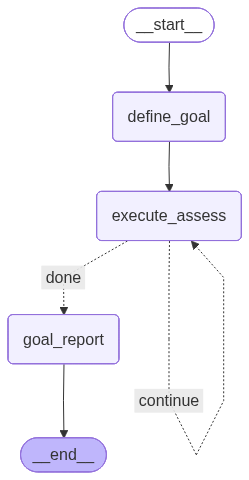


GOAL-ORIENTED EXECUTION RUN
  [Goal Definer] Goal set with 4 criteria:
    [1] Total learning time required for LangGraph and MCP fundamentals is ≤60 hours (6 weeks × 10 hours/week), as verified by estimate_time tool
    [2] Intermediate Python skills meet all prerequisites for LangGraph and MCP, as verified by check_prerequisites tool
    [3] Difficulty level of LangGraph and MCP is rated as 'intermediate' or lower for developers with Python background, as verified by assess_difficulty tool
    [4] At least 3 high-quality learning resources (tutorials, documentation, or courses) are available for LangGraph and MCP, as verified by search_resources tool
  [Execute+Assess] Iter 1: Start by verifying the time requirement, as this is a hard constraint for the goal. If learning fundamentals requires more than 60 hours, the goal is not achievable regardless of other factors. This provides the most critical information first. → Estimated time to complete all 'python' resources: 35 hours....


In [11]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Optional
from langgraph.graph import StateGraph, START, END


# ── Goal and progress schemas ──────────────────────────────────────────────────
class GoalCriterion(BaseModel):
    criterion_id: int
    description:  str  = Field(description="Measurable condition that must be true for the goal to be achieved")
    met:          bool = Field(default=False)
    evidence:     Optional[str] = Field(default=None, description="What was found that satisfies this criterion")

class GoalDefinition(BaseModel):
    goal:     str
    criteria: List[GoalCriterion]

class ProgressAssessment(BaseModel):
    criteria_status: List[GoalCriterion] = Field(
        description="Updated status of each criterion — set met=True and add evidence for criteria that are now satisfied"
    )
    next_action: str = Field(description="What to do next to satisfy remaining unmet criteria")
    next_tool:   str = Field(description="Which tool to call next")
    next_input:  str = Field(description="Input for the next tool call")

class GoalState(TypedDict):
    goal_definition: Optional[GoalDefinition]
    raw_goal:        str
    work_log:        List[str]
    iterations:      int
    final_report:    Optional[str]


# ── Nodes ──────────────────────────────────────────────────────────────────────
goal_definer_llm  = llm.with_structured_output(GoalDefinition)
progress_check_llm = llm.with_structured_output(ProgressAssessment)

def define_goal_node(state: GoalState) -> dict:
    """Converts the raw goal into measurable success criteria."""
    goal_def = goal_definer_llm.invoke(
        f"Convert this goal into 4 specific, measurable success criteria:\n"
        f"Goal: {state['raw_goal']}\n"
        f"Each criterion must be verifiable with the available tools: "
        f"search_resources, check_prerequisites, estimate_time, assess_difficulty"
    )
    print(f"  [Goal Definer] Goal set with {len(goal_def.criteria)} criteria:")
    for c in goal_def.criteria:
        print(f"    [{c.criterion_id}] {c.description}")
    return {"goal_definition": goal_def}

def execute_and_assess_node(state: GoalState) -> dict:
    """
    Two-in-one node: executes the next recommended action, then immediately
    assesses progress against the success criteria.
    This tight loop prevents unnecessary extra iterations.
    """
    goal = state["goal_definition"]
    unmet = [c for c in goal.criteria if not c.met]

    assessment = progress_check_llm.invoke(
        f"Goal: {goal.goal}\n"
        f"Success criteria:\n" + "\n".join(f"  [{c.criterion_id}] {'✅' if c.met else '❌'} {c.description}" for c in goal.criteria) + "\n"
        f"Work done so far:\n" + ("\n".join(state["work_log"][-5:]) if state["work_log"] else "Nothing yet") + "\n"
        f"Unmet criteria: {[c.description for c in unmet]}\n"
        f"Available tools: search_resources, check_prerequisites, estimate_time, assess_difficulty\n"
        f"Which criteria can now be marked as met based on work done? "
        f"What is the single best next action to satisfy one of the remaining unmet criteria?"
    )

    # Execute the recommended action
    tool_map = {
        "search_resources":   search_resources,
        "check_prerequisites":check_prerequisites,
        "estimate_time":      estimate_time,
        "assess_difficulty":  assess_difficulty,
    }
    tool_fn = tool_map.get(assessment.next_tool)
    if tool_fn:
        if assessment.next_tool == "assess_difficulty":
            parts = assessment.next_input.split("|")
            result = tool_fn.invoke({"topic": parts[0].strip(), "experience_level": parts[1].strip() if len(parts) > 1 else "beginner"})
        else:
            result = tool_fn.invoke(assessment.next_input)
    else:
        result = f"Tool '{assessment.next_tool}' not found."

    # Merge criterion status updates from assessment
    updated_criteria = {c.criterion_id: c for c in goal.criteria}
    for updated in assessment.criteria_status:
        if updated.met:
            updated_criteria[updated.criterion_id] = updated

    goal.criteria = list(updated_criteria.values())
    met_count = sum(1 for c in goal.criteria if c.met)

    print(f"  [Execute+Assess] Iter {state['iterations'] + 1}: "
          f"{assessment.next_action} → {result[:60]}...")
    print(f"    Progress: {met_count}/{len(goal.criteria)} criteria met")

    return {
        "goal_definition": goal,
        "work_log": state["work_log"] + [f"Action: {assessment.next_action} | Result: {result[:80]}"],
        "iterations": state["iterations"] + 1,
    }

def goal_report_node(state: GoalState) -> dict:
    goal = state["goal_definition"]
    met  = sum(1 for c in goal.criteria if c.met)
    report = llm.invoke(
        f"Goal: {goal.goal}\n"
        f"Criteria met: {met}/{len(goal.criteria)}\n"
        f"Details:\n" + "\n".join(f"  {'✅' if c.met else '❌'} {c.description}" + (f" — {c.evidence}" if c.evidence else "") for c in goal.criteria) + "\n"
        f"Write a concise goal achievement report."
    ).content
    return {"final_report": report}

# ── Routing ────────────────────────────────────────────────────────────────────
def check_goal_achieved(state: GoalState) -> str:
    goal = state["goal_definition"]
    all_met = all(c.met for c in goal.criteria)
    timeout = state["iterations"] >= 6   # safety limit
    if all_met:
        print("  ✅ All criteria met — goal achieved!")
        return "done"
    if timeout:
        print("  ⏱️  Max iterations reached — stopping.")
        return "done"
    return "continue"

# ── Build graph ────────────────────────────────────────────────────────────────
builder = StateGraph(GoalState)
builder.add_node("define_goal",    define_goal_node)
builder.add_node("execute_assess", execute_and_assess_node)
builder.add_node("goal_report",    goal_report_node)

builder.add_edge(START, "define_goal")
builder.add_edge("define_goal", "execute_assess")
builder.add_conditional_edges("execute_assess", check_goal_achieved,
                               {"continue": "execute_assess", "done": "goal_report"})
builder.add_edge("goal_report", END)

goal_graph = builder.compile()
display(Image(goal_graph.get_graph().draw_mermaid_png()))

print("\n" + "=" * 65)
print("GOAL-ORIENTED EXECUTION RUN")
print("=" * 65)

result = goal_graph.invoke({
    "raw_goal":       "Determine whether an intermediate Python developer can realistically start LangGraph and MCP within 6 weeks at 10 hours per week",
    "goal_definition":None,
    "work_log":       [],
    "iterations":     0,
    "final_report":   None,
})

print("\n=== GOAL REPORT ===")
print(result["final_report"])

---
## Step 7 – Hierarchical Planning: Orchestrators and Specialists

**Hierarchical planning** organises work across multiple levels of abstraction:

- **Level 1 — Orchestrator**: Breaks the high-level goal into phases and assigns each phase to a specialist
- **Level 2 — Specialist agents**: Each specialist handles one phase with its own tools and sub-plan
- **Level 1 again — Orchestrator**: Synthesises all specialist outputs into the final result

```
                 [Orchestrator]
                   ↙    ↓    ↘
      [Curriculum  [Resource  [Schedule
       Specialist] Specialist] Specialist]
           ↓            ↓           ↓
       subtasks     subtasks    subtasks
                   ↘    ↓    ↙
                 [Orchestrator]
                 (synthesises)
                      ↓
                   FINAL PLAN
```

**Why hierarchy beats a flat approach:**  
- Each specialist has a **narrow, well-defined scope** → better quality outputs
- Specialists can run **in parallel** (not shown here for simplicity)
- The orchestrator stays at a high level → easier to reason about the overall goal
- Adding a new specialist does not change the orchestrator's logic

/var/folders/1h/8kw0jbt134d6sgxbnf23qrhr0000gn/T/ipykernel_55245/2579160131.py:33: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  curriculum_agent = create_react_agent(
/var/folders/1h/8kw0jbt134d6sgxbnf23qrhr0000gn/T/ipykernel_55245/2579160131.py:44: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  resource_agent = create_react_agent(
/var/folders/1h/8kw0jbt134d6sgxbnf23qrhr0000gn/T/ipykernel_55245/2579160131.py:54: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  schedule_agent = create_react_age

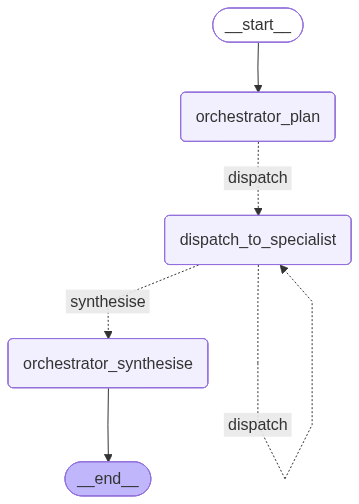

In [12]:
from pydantic import BaseModel, Field
from typing import List, Optional, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent


# ── Orchestrator-level schemas ─────────────────────────────────────────────────
class Phase(BaseModel):
    """A high-level phase of the learning plan, assigned to one specialist."""
    phase_id:    int
    name:        str
    objective:   str = Field(description="What this phase must accomplish")
    specialist:  str = Field(description="Which specialist handles this: curriculum / resources / schedule")
    input_data:  str = Field(description="The key information this specialist needs to do its job")

class MasterPlan(BaseModel):
    """The orchestrator's high-level plan."""
    student_profile: str
    overall_goal:    str
    phases:          List[Phase]

class HierarchicalState(TypedDict):
    task:              str
    master_plan:       Optional[MasterPlan]
    current_phase:     int
    specialist_outputs: List[str]
    final_plan:        Optional[str]


# ── Specialist agents (each is a mini ReAct agent with focused tools) ─────────

# Curriculum specialist: focuses on WHAT to learn and in what order
curriculum_agent = create_react_agent(
    llm,
    tools=[check_prerequisites, assess_difficulty],
    prompt=(
        "You are a Curriculum Specialist. Your job is to determine the correct ORDER "
        "of topics to study and verify prerequisites. Use check_prerequisites and "
        "assess_difficulty to build a sequenced curriculum."
    ),
)

# Resource specialist: focuses on WHAT materials to use
resource_agent = create_react_agent(
    llm,
    tools=[search_resources, estimate_time],
    prompt=(
        "You are a Resource Specialist. Your job is to find the best learning materials "
        "and estimate time requirements. Use search_resources and estimate_time."
    ),
)

# Schedule specialist: focuses on HOW to fit learning into a timeline
schedule_agent = create_react_agent(
    llm,
    tools=[create_schedule, save_progress],
    prompt=(
        "You are a Schedule Specialist. Your job is to build a realistic weekly schedule "
        "and record milestones. Use create_schedule and save_progress."
    ),
)

SPECIALIST_MAP = {
    "curriculum": curriculum_agent,
    "resources":  resource_agent,
    "schedule":   schedule_agent,
}


# ── Orchestrator node: creates the master plan ────────────────────────────────
orchestrator_llm = llm.with_structured_output(MasterPlan)

def orchestrator_plan(state: HierarchicalState) -> dict:
    """Level 1: Creates the master plan and assigns phases to specialists."""
    master = orchestrator_llm.invoke(
        f"You are an orchestrator. Break this task into 3 phases:\n"
        f"Task: {state['task']}\n"
        f"Phase 1: curriculum specialist (what and in what order to learn)\n"
        f"Phase 2: resources specialist (what materials and time required)\n"
        f"Phase 3: schedule specialist (build timeline and record milestones)\n"
        f"Each phase must specify a clear objective and what input the specialist needs."
    )
    print(f"  [Orchestrator] Master plan created with {len(master.phases)} phases:")
    for p in master.phases:
        print(f"    Phase {p.phase_id} [{p.specialist}]: {p.objective}")
    return {"master_plan": master, "current_phase": 0}


# ── Dispatcher node: runs the current phase's specialist ─────────────────────
def dispatch_to_specialist(state: HierarchicalState) -> dict:
    """Level 1 → Level 2: Hands the current phase to the right specialist agent."""
    phase = state["master_plan"].phases[state["current_phase"]]
    specialist = SPECIALIST_MAP.get(phase.specialist)

    if not specialist:
        output = f"No specialist found for '{phase.specialist}'"
    else:
        print(f"  [Dispatcher] → Calling {phase.specialist} specialist for: {phase.objective}")
        # Each specialist gets its phase objective as a focused sub-task
        specialist_result = specialist.invoke({
            "messages": [("user", f"{phase.objective}\nContext: {phase.input_data}")]
        })
        # Extract the final message from the specialist's ReAct trace
        output = specialist_result["messages"][-1].content
        print(f"    Specialist output: {output[:120]}...")

    return {
        "current_phase":       state["current_phase"] + 1,
        "specialist_outputs":  state["specialist_outputs"] + [f"[{phase.specialist}]: {output}"],
    }


# ── Synthesiser node: orchestrator combines all specialist outputs ─────────────
def orchestrator_synthesise(state: HierarchicalState) -> dict:
    """Level 1 again: Orchestrator reads all specialist outputs and produces the final plan."""
    print("  [Orchestrator] Synthesising all specialist outputs...")
    all_outputs = "\n\n".join(state["specialist_outputs"])
    final = llm.invoke(
        f"You are the orchestrator. Combine these specialist reports into a single, "
        f"coherent learning plan:\n\n{all_outputs}\n\n"
        f"Write a clear, actionable final plan that a student can follow immediately."
    ).content
    return {"final_plan": final}


# ── Routing ────────────────────────────────────────────────────────────────────
def phases_remaining(state: HierarchicalState) -> str:
    if state["current_phase"] < len(state["master_plan"].phases):
        return "dispatch"
    return "synthesise"

# ── Build the hierarchical graph ───────────────────────────────────────────────
progress_store.clear()

builder = StateGraph(HierarchicalState)
builder.add_node("orchestrator_plan",       orchestrator_plan)
builder.add_node("dispatch_to_specialist",  dispatch_to_specialist)
builder.add_node("orchestrator_synthesise", orchestrator_synthesise)

builder.add_edge(START, "orchestrator_plan")
builder.add_conditional_edges(
    "orchestrator_plan",
    lambda s: "dispatch",
    {"dispatch": "dispatch_to_specialist"},
)
builder.add_conditional_edges(
    "dispatch_to_specialist",
    phases_remaining,
    {"dispatch": "dispatch_to_specialist", "synthesise": "orchestrator_synthesise"},
)
builder.add_edge("orchestrator_synthesise", END)

hierarchical_graph = builder.compile()
display(Image(hierarchical_graph.get_graph().draw_mermaid_png()))

In [13]:
print("=" * 65)
print("HIERARCHICAL PLANNING RUN")
print("=" * 65)

result = hierarchical_graph.invoke({
    "task": (
        "Create a complete 12-week AI agent development curriculum for an "
        "intermediate Python developer who wants to master LangGraph, MCP, and A2A "
        "studying 8 hours per week."
    ),
    "master_plan":         None,
    "current_phase":       0,
    "specialist_outputs":  [],
    "final_plan":          None,
})

print("\n=== FINAL PLAN (synthesised by orchestrator) ===")
print(result["final_plan"])

HIERARCHICAL PLANNING RUN
  [Orchestrator] Master plan created with 3 phases:
    Phase 1 [curriculum]: Define the complete learning sequence, core topics, skill progression, and learning outcomes for mastering LangGraph, MCP, and A2A over 12 weeks
    Phase 2 [resources]: Identify and curate all necessary learning materials (documentation, tutorials, courses, code examples), estimate time requirements per topic, and validate resource availability and quality
    Phase 3 [schedule]: Build a detailed 12-week timeline with weekly breakdowns, assign topics to weeks, define measurable milestones, and create a progress tracking system
  [Dispatcher] → Calling curriculum specialist for: Define the complete learning sequence, core topics, skill progression, and learning outcomes for mastering LangGraph, MCP, and A2A over 12 weeks
    Specialist output: Perfect! Now I have all the information needed. Let me create your comprehensive 12-week curriculum:

---

# **12-WEEK M...
  [Dispatcher] → C

KeyboardInterrupt: 

---
## Step 8 – Teaching Notes

---

### Why planning is what makes systems truly agentic

A non-agentic system responds to one input and stops. It has no concept of:
- **What comes next** — it cannot decide what to do after answering
- **Whether it is done** — it cannot check its own progress
- **What to do when it fails** — it cannot recover from unexpected results

Planning gives an agent all three. Without planning, a system is a question-answering API.  
With planning, it becomes an autonomous agent that can own multi-step, open-ended work.

---

### The six patterns — when each one shines

| Pattern | Core idea | Best when | Weakness |
|---|---|---|---|
| **ReAct** | Reason → Act → Observe, repeat | Path unknown upfront; each step reveals the next | Slow for well-structured tasks; no upfront visibility |
| **Plan-and-Execute** | Plan the whole thing, then execute | Task is well-structured and predictable | Fails silently when the plan is wrong |
| **Task Decomposition** | Break down until atomic | Task is too complex to plan at one level | Decomposition itself can be incorrect or incomplete |
| **Dynamic Planning** | Replan on failure | Real-world tasks where steps can fail or surprise | Adds complexity; risk of infinite replan loops |
| **Goal-oriented** | Check criteria, keep going until met | Success is measurable; steps are hard to count upfront | May iterate unnecessarily; needs clear criteria |
| **Hierarchical** | Orchestrate specialists | Large tasks requiring diverse expertise | More moving parts; harder to debug |

---

### How the patterns build on each other

```
ReAct
  └── adds upfront planning → Plan-and-Execute
        └── adds recursive breakdown → Task Decomposition
              └── adds failure recovery → Dynamic Planning
                    └── adds success measurement → Goal-oriented
                          └── adds multi-level coordination → Hierarchical
```

In production systems, you will often **combine** patterns:
- A **Hierarchical** orchestrator delegates to **Plan-and-Execute** specialists
- Each specialist uses **Dynamic Planning** internally
- Terminal nodes run **ReAct** for open-ended sub-tasks
- The whole system is wrapped in **Goal-oriented** evaluation

---

### Structured output is the glue

Every planning pattern in this notebook uses Pydantic structured output (from Concept 54) for the plan itself:
- `LearningPlan`, `DynamicPlan`, `MasterPlan` — all Pydantic models
- Routing decisions (`route_after_execution`, `phases_remaining`) read **typed fields** — no string parsing
- Plans are serialisable — they can be stored, logged, reviewed, and resumed

**Rule of thumb:** whenever your LLM produces a plan, use structured output. Free-form plan text is hard to execute programmatically.

---

### LangGraph concepts used in each pattern

| Pattern | Key LangGraph features |
|---|---|
| ReAct | `create_react_agent`, `ToolNode`, `tools_condition` |
| Plan-and-Execute | `StateGraph`, conditional edges, loop until counter exhausted |
| Task Decomposition | Pydantic recursive model, structured output, pure Python recursion |
| Dynamic Planning | Conditional edges with 3 routes, replan counter as loop guard |
| Goal-oriented | Self-loop (`execute_assess → execute_assess`), progress check as routing condition |
| Hierarchical | Sub-agents as nodes, orchestrator-level routing, `create_react_agent` for specialists |

---

### Common design mistakes and fixes

| Mistake | Fix |
|---|---|
| Infinite ReAct loops | Add `max_iterations` to `create_react_agent` or add a counter to state |
| Plan-and-Execute with no error handling | Add a `status` field to each step; route to `replanner` on failure |
| Decomposition with no depth limit | Always add `max_depth` guard in the decomposer |
| Goal-oriented with vague criteria | Criteria must be verifiable with available tools — if you cannot check it, it is not a criterion |
| Hierarchical specialists that overlap | Each specialist must have a narrow, non-overlapping scope; the orchestrator merges at the end |
| Replanning without a limit | `replan_count < 3` (or similar) in every dynamic planning graph |

---

### Classroom extension ideas

| Idea | What to build |
|---|---|
| Add a ReAct fallback | When Plan-and-Execute fails, hand off to a ReAct agent as a recovery strategy |
| Parallel specialists | In Hierarchical, run all specialists simultaneously with `asyncio.gather` instead of sequentially |
| Human-in-the-loop approval | After Planner produces a plan, pause for human review before Executor runs (HITL from Concept 11) |
| Cross-plan learning | Store successful plans in memory; seed the Planner with similar past plans |
| Multi-goal orchestration | Give the agent two goals at once; use Hierarchical to split and conquer |